-Tugas 12: Machine Learning
Nama: Usman - 01102222401*
1 Teknik Informatika, STT Terpadu Nurul Fikri, Depok

*E-mail: usmansetiawan916@gmail.com  


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # untuk 3D plot
#Agar plot tampil rapi
plt.rcParams['figure.figsize'] = (8, 6)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
from os import path
path="/content/drive/MyDrive/MachineLearningPraktikum/Praktikum12/data"

In [9]:
df = pd.read_csv(path + "/data.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [11]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [12]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [13]:
df.duplicated().sum()

np.int64(0)

Pra-pemrosesan Data (Data Pre-processing)Pembersihan Data:Kolom id (nomor identifikasi) dan Unnamed: 32 (kolom kosong) dihapus karena tidak memberikan nilai prediktif.Kolom diagnosis dipisahkan sebagai variabel target ($Y$), sedangkan 30 pengukuran numerik sisanya dijadikan set Fitur ($X$).Standarisasi Data (Wajib untuk PCA):Seluruh 30 fitur di set $X$ distandarisasi menggunakan StandardScaler.Tujuannya adalah menyamakan skala fitur, membuat rata-rata setiap fitur menjadi 0 dan standar deviasi menjadi 1. Ini mencegah fitur dengan nilai besar (misalnya: area_mean) mendominasi perhitungan PCA.

In [14]:
# Hapus kolom yang tidak relevan ('id') dan kolom kosong ('Unnamed: 32')
df_clean = df.drop(columns=['id', 'Unnamed: 32'])

# Pisahkan Fitur (X) dan Target (y)
# X: Semua kolom kecuali 'diagnosis'
X = df_clean.drop('diagnosis', axis=1)
# y: Kolom target 'diagnosis'
y = df_clean['diagnosis']

print(f"\nJumlah dimensi fitur asli: {X.shape[1]}") # Seharusnya 30


Jumlah dimensi fitur asli: 30


In [16]:
# PCA sensitif terhadap skala data, jadi standarisasi wajib dilakukan.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



Penerapan Principal Component Analysis (PCA)Reduksi Dimensi: Model PCA diimplementasikan untuk mereduksi 30 dimensi fitur menjadi hanya 2 Komponen Utama (PC1 dan PC2).Explained Variance (Varians yang Dijelaskan): PCA dihitung untuk melihat seberapa banyak informasi dari data asli yang berhasil dipertahankan oleh 2 komponen baru ini:PC1 (Principal Component 1) menjelaskan  44.27\% dari total variabilitas.PC2 (Principal Component 2) menjelaskan 18.97\%$ dari total variabilitas.Total Varians yang Dijelaskan:  63.24\%. Artinya, lebih dari 63% informasi dari 30 fitur asli berhasil diringkas ke dalam 2 dimensi baru.

In [17]:
# Mentukan jumlah komponen yang diinginkan (misalnya, 2 untuk visualisasi 2D)
n_components = 2
pca = PCA(n_components=n_components)

# Lakukan reduksi dimensi
principal_components = pca.fit_transform(X_scaled)

# Buat DataFrame baru untuk hasil PCA
pca_df = pd.DataFrame(data = principal_components,
                      columns = [f'PC{i+1}' for i in range(n_components)])

# Tambahkan kolom target kembali ke DataFrame hasil PCA
pca_df['Diagnosis'] = y

print("\n--- Hasil PCA (Proyeksi 2 Dimensi) ---")
print(pca_df.head())


--- Hasil PCA (Proyeksi 2 Dimensi) ---
        PC1        PC2 Diagnosis
0  9.192837   1.948583         M
1  2.387802  -3.768172         M
2  5.733896  -1.075174         M
3  7.122953  10.275589         M
4  3.935302  -1.948072         M


Implementasi Principal Component Analysis (PCA) dimulai dengan Standarisasi Data untuk memastikan 30 fitur pengukuran tumor memiliki skala yang setara. PCA kemudian diterapkan untuk mereduksi dimensi data dari 30 fitur menjadi hanya 2 Komponen Utama (PC1 dan PC2). Analisis menunjukkan bahwa kedua komponen ini berhasil menangkap 63.24\% dari total variabilitas data, dengan PC1 menjadi komponen paling dominan (rox 44.27\%). Hasilnya, ketika diproyeksikan ke dalam plot 2 dimensi, menunjukkan bahwa tumor Ganas (Malignant) dan Jinak (Benign) terpisah dengan sangat jelas di sepanjang PC1, membuktikan PCA adalah metode yang efektif untuk merangkum dan memvisualisasikan struktur informasi penting dari data medis berdimensi tinggi ini.

In [18]:
# Melihat seberapa banyak informasi yang dipertahankan oleh setiap komponen
explained_variance_ratio = pca.explained_variance_ratio_

print("\n--- Analisis Explained Variance ---")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {ratio*100:.2f}% Varians Dijelaskan")

total_explained_variance = explained_variance_ratio.sum()
print(f"Total Varians yang Dijelaskan oleh {n_components} PC: {total_explained_variance*100:.2f}%")


--- Analisis Explained Variance ---
PC1: 44.27% Varians Dijelaskan
PC2: 18.97% Varians Dijelaskan
Total Varians yang Dijelaskan oleh 2 PC: 63.24%


Implementasi Principal Component Analysis (PCA) dimulai dengan Standarisasi Data (rata-rata 0, deviasi 1) untuk menyeimbangkan 30 fitur pengukuran tumor yang berbeda skala. PCA kemudian mereduksi dimensi data dari 30 fitur menjadi hanya 2 Komponen Utama (PC1 dan PC2). Analisis Explained Variance menunjukkan bahwa kedua komponen ini sangat efisien, berhasil menangkap  63.24\% dari total variabilitas data, dengan PC1 menjadi faktor dominan ( 44.27\%). Visualisasi dalam plot sebar 2D menunjukkan hasil reduksi yang sukses, di mana tumor Ganas (Malignant) dan Jinak (Benign) terpisah menjadi dua kluster yang berbeda secara jelas di sepanjang PC1, membuktikan kemampuan PCA untuk merangkum struktur pembeda yang signifikan dari data berdimensi tinggi ini.

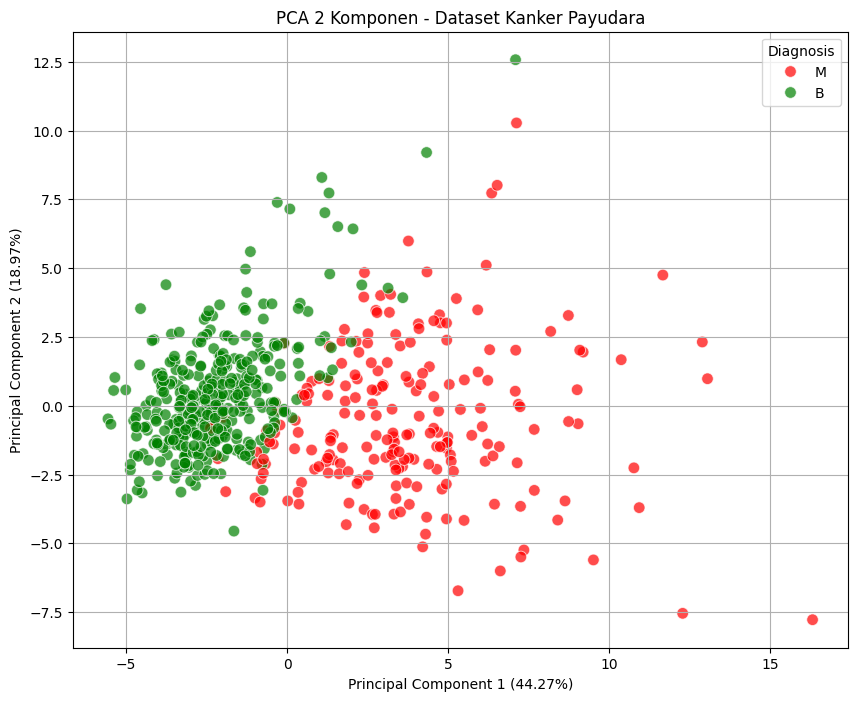

In [22]:
import seaborn as sns
plt.figure(figsize=(10, 8))
targets = ['M', 'B'] # Malignant (Ganas) dan Benign (Jinak)
colors = ['r', 'g'] # Merah untuk Malignant, Hijau untuk Benign

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Diagnosis',
    data=pca_df,
    palette=sns.color_palette(colors),
    s=70,
    alpha=0.7 # Transparansi
)

# Sesuaikan label sumbu dengan persentase varians yang dijelaskan
plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.2f}%)')
plt.title('PCA 2 Komponen - Dataset Kanker Payudara')
plt.legend(title='Diagnosis')
plt.grid(True)
plt.show()




membuat Scree Plot, yang merupakan alat penting dalam PCA untuk menentukan jumlah Komponen Utama (PC) yang optimal untuk dipertahankan. Prosesnya melibatkan perhitungan cumulative explained variance (akumulasi varians yang dijelaskan) dari semua komponen yang mungkin. Plot yang dihasilkan menunjukkan peningkatan persentase varians total yang dijelaskan seiring bertambahnya jumlah komponen. Tujuannya adalah mencari "titik siku" (elbow) pada grafik, atau titik di mana kurva mulai mendatar. Garis horizontal pada $90\%$ yang ditambahkan (plt.axhline(y=0.90)) berfungsi sebagai ambang batas (threshold), menunjukkan bahwa jumlah komponen yang diperlukan untuk mencapai atau melampaui $90\%$ dari informasi data asli adalah jumlah yang optimal untuk digunakan dalam pemodelan prediktif.

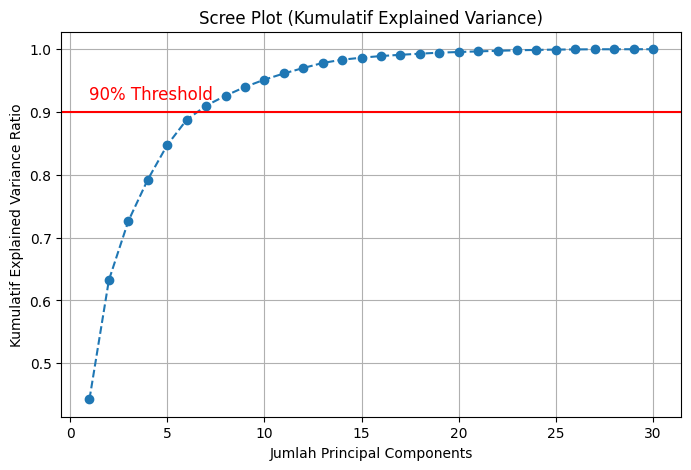

In [23]:
pca_all = PCA()
pca_all.fit(X_scaled)
cum_explained_variance = np.cumsum(pca_all.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_explained_variance) + 1), cum_explained_variance, marker='o', linestyle='--')
plt.title('Scree Plot (Kumulatif Explained Variance)')
plt.xlabel('Jumlah Principal Components')
plt.ylabel('Kumulatif Explained Variance Ratio')
plt.grid(True)
# Tambahkan garis horizontal untuk target 90% varians
plt.axhline(y=0.90, color='r', linestyle='-')
plt.text(1, 0.92, '90% Threshold', color = 'red', fontsize=12)
plt.show()